In [3]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

from mcmc import *

from astropy.io import fits
from nn_helpers import MoogStokesNN
from spectra import SpectralDataForMoogStokes, setup_regions_plot

## How to use the neural network

Make sure that the model weights (nn_region_0.pt, nn_region_1.pt, ...) and region information (region_info.txt) are located in the appropriate directory.

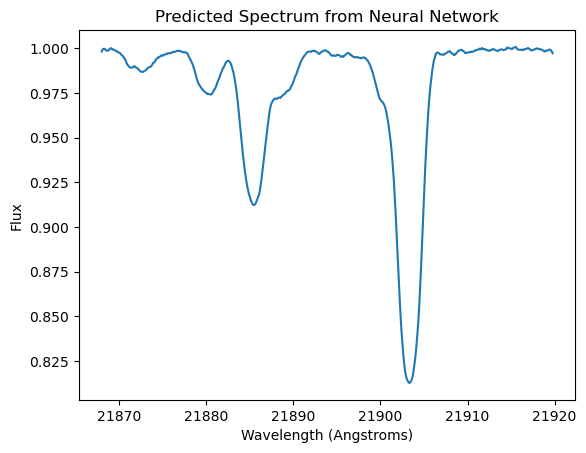

In [ ]:
# use the MoogStokesNN class to generate models like this. the neural network is
# instantiated in a class like this so that we don't import the weights every time
# we want to generate a model spectrum.
moognn = MoogStokesNN()
testmodel = moognn.make_moogstokes_model(Teff=3982, logg=3.9, rK=0.2, B=1.6, vsini=23, region=2)
plt.figure()
plt.plot(testmodel.x, testmodel.y)
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Flux")
plt.title("Predicted Spectrum from Neural Network")
plt.show()

## Prepare data

Find renormalizations and shifts manually here. I asked Claude to make "spectrum_gui.py" to help preprocess data more quickly. You're also welcome to use that script (I can explain how it works later and/or you can see the mcmc_proplyd.ipynb to see how I retrieve the preprocessing parameters).

[Nyquist sampling] Factor applied: 3. Old SNR = 122.69984424328779
[Nyquist sampling] Factor applied: 3. New SNR = 211.14261408384144


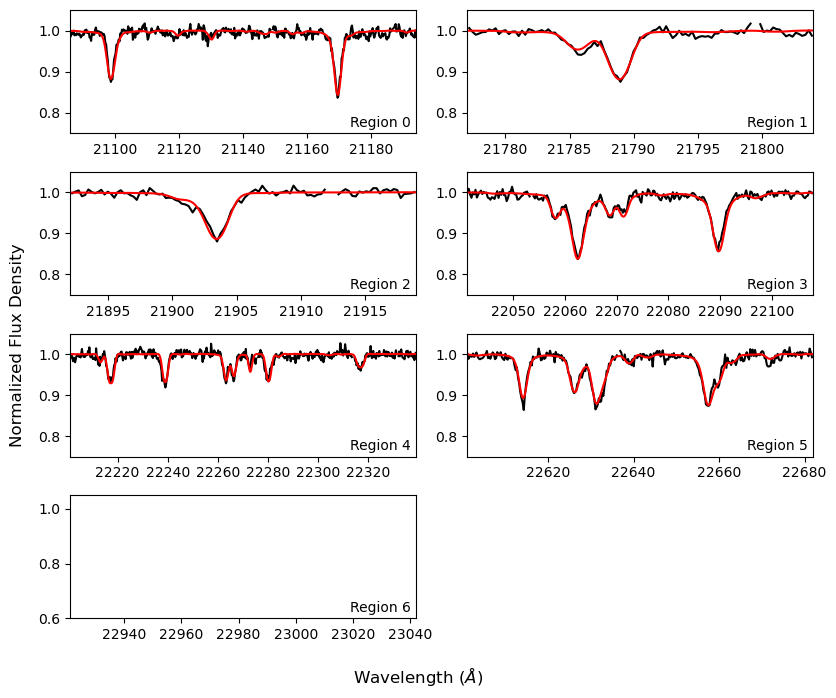

In [5]:
moognn = MoogStokesNN()

#shifts = np.array([-33, -33, -30, -33, -33, -33, -33])
shifts = np.array([-11, -11, -10, -11, -11, -11, -11])

renormalization = np.array([1.002, 1.0, 1.004, 1.001, 1.003, 1.004, 1.001])
regions = range(6)
regions = [0, 1, 2, 3, 4, 5]

resolution = 10 * 2e4 / 75000 # iSHELL - 0."375 slit for IP
resolution = 0.1

# The SpectralDataForMoogStokes class stores useful tuning parameters like the
# renormalization and Doppler shift for each region...
testdata = SpectralDataForMoogStokes("data/science/test/Spectrum_CI_Tau_Class-II-sources.nspec",
                                     name="CI Tau", regions=regions, shifts=shifts, renormalization=renormalization,
                                     kernel="KECK", resolution=resolution)
testdata.Nyquist_bin_spectrum(3)

# Parameters from Christian's paper with traditional MoogStokes
Teff = 3888
logg = 3.74
rK = 1.87
B = 1.78
vsini = 12.71

fig, axs = setup_regions_plot()
for r in regions:
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label="Observed", color="black")
    testmodel = moognn.make_moogstokes_model(Teff=Teff, logg=logg, rK=rK, B=B, vsini=vsini, region=r)
    if testdata.resolution is not None or testdata.kernel is not None:
        testmodel.resolution_change(resolution=testdata.resolution, Kernel=testdata.kernel)
    axs[r].plot(testmodel.x, testmodel.y, label="Model", color="red")
    axs[r].set_ylim(0.75, 1.05)

plt.show()

## Run MCMC

In [19]:
nwalkers = 16
# initial walker positions - only do a few right now because I'm lazy
pos = np.random.uniform(low=[3200, 2.5, 0.0, 0.0, 2.0], high=[7000, 5.1, 1.0, 3.0, 57], size=(nwalkers, 5))
ndim = pos.shape[1]

# See the lnprob function in mcmc.py
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(testdata, moognn))
sampler.run_mcmc(pos, 2000, progress=True);

100%|██████████| 2000/2000 [06:06<00:00,  5.45it/s]


See MCMC results

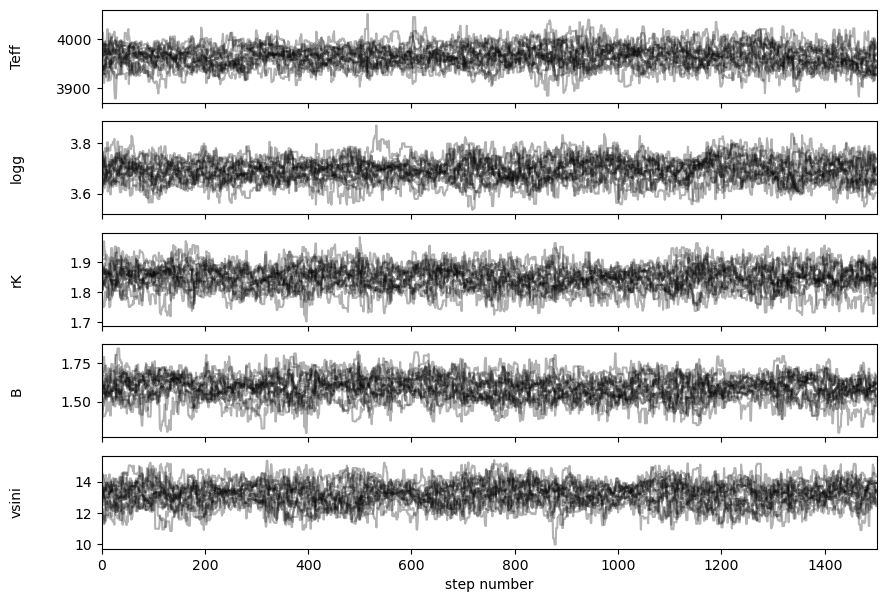

In [20]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
discard = 500
samples = sampler.get_chain(discard=discard)
flat_samples = sampler.get_chain(discard=discard, thin=5, flat=True)
labels = ["Teff", "logg", "rK", "B", "vsini"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

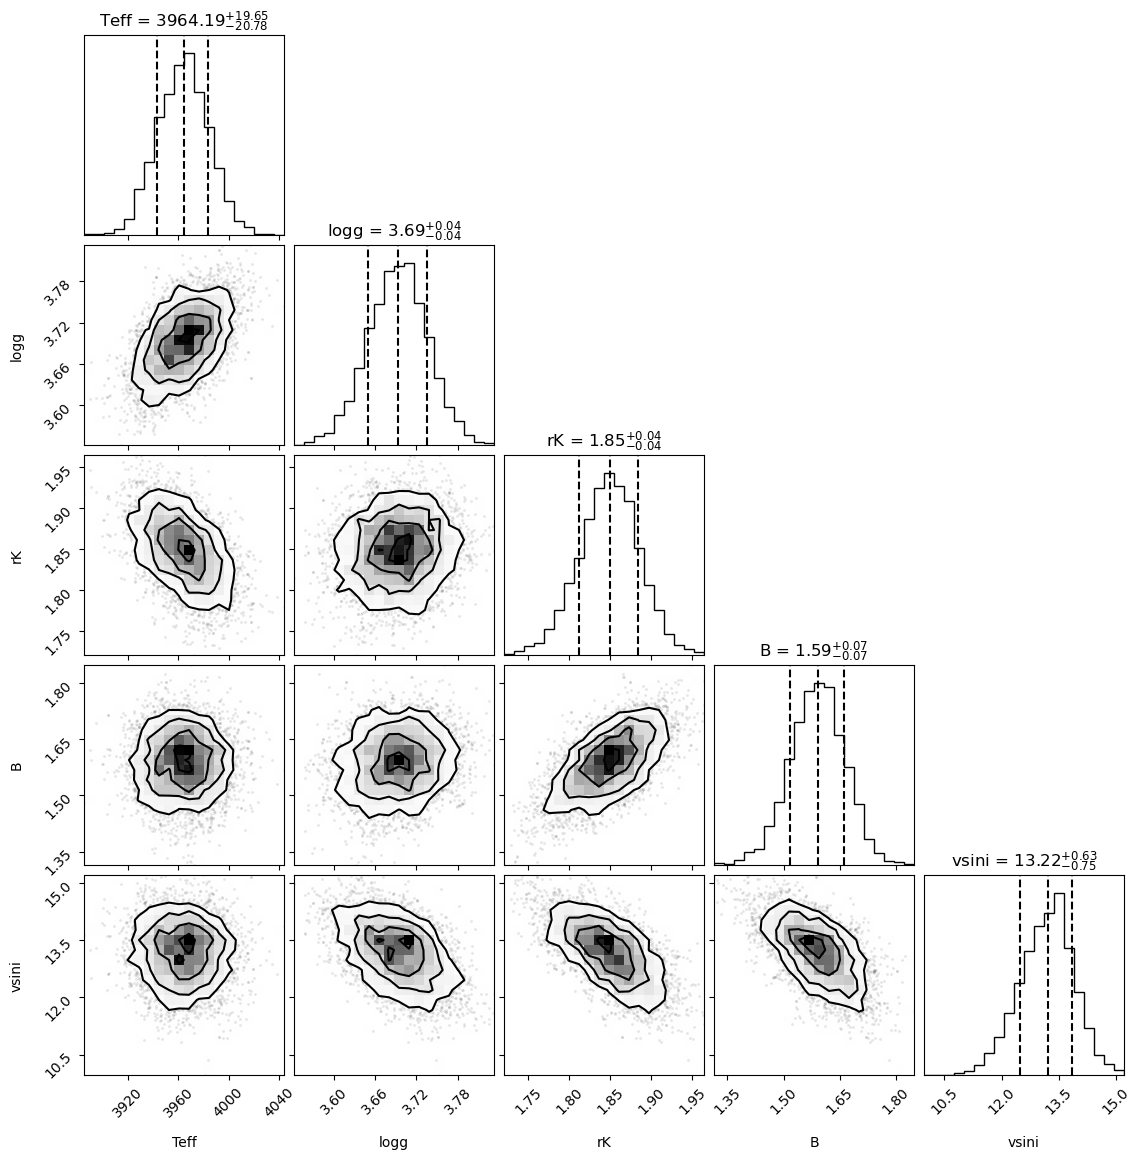

In [21]:
# Get truths as percentiles
medians = np.median(flat_samples, axis=0)
labels = ["Teff", "logg", "rK", "B", "vsini"]

fig = corner.corner(
    flat_samples, labels=labels,
    quantiles = [0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12}
)

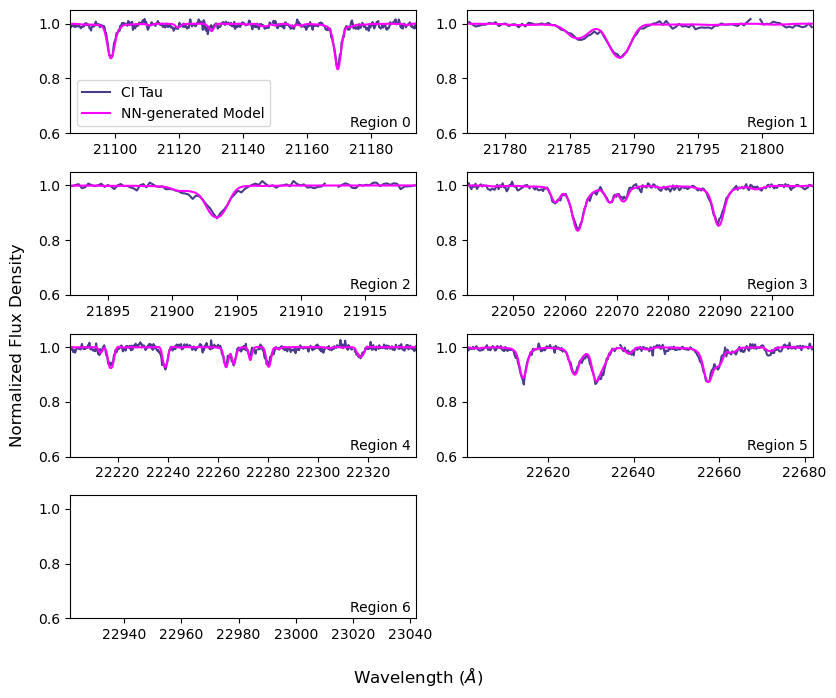

In [22]:
fig, axs = setup_regions_plot()

for r in testdata.regions:
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label=testdata.name, color="darkslateblue")
    fitted_model = moognn.make_moogstokes_model(Teff=medians[0], logg=medians[1], rK=medians[2], B=medians[3], vsini=medians[4], region=r)
    axs[r].plot(fitted_model.x, fitted_model.y, label="NN-generated Model", color="fuchsia")
    axs[r].set_ylim(0.6, 1.05)

    if r == 0:
        axs[r].legend()

plt.show()

## Rescale the errors

...with the reduced chi-squared value and run the above cells again

In [17]:
# Calculate reduced chi-squared for the best-fit model
chi2 = -2 * lnlike(medians, testdata, moognn)

dof = 0
for r in testdata.regions:
    masks = testdata.masks.get(r, [])
    yreg = testdata.get_region(r)[1]
    if not masks:
        dof += np.count_nonzero(~np.isnan(yreg))
    else:
        keep = np.zeros(len(x), dtype=bool)
        for xlo, xhi in masks:
            keep |= (x >= xlo) & (x <= xhi)
        dof += np.count_nonzero(~np.isnan(yreg[keep]))

dof += len(medians) # number of parameters
print(dof)

reduced_chi2 = chi2 / dof
print(reduced_chi2)

1698
1.0000000000000002


In [18]:
testdata.rescale_yerr(np.sqrt(reduced_chi2))

[yerr rescaled] Factor applied: 1.0. Total scaling so far: 1.8084338453454094
